**Heart Disease Prediction Using Machine Learning.**

The goal of this exercise is to build a machine learning model capable of predicting the presence of heart disease based on patient health data. Ensure you understand the meaning of each feature (e.g., age, cholesterol, blood pressure, etc.).

# **1. Data Understanding**
* 1.1. Descriptive Statistics
* 1.2. Duplicated Data
* 1.3. Null Data
* and so on...

# **2. Exploratory Data Analysis (EDA)**

# **3. Data Preparation**
* 3.1. Data Cleaning
* 3.2. Data Training
* 3.3. and so on...

# **4. Modeling and Evaluation**
**Model comparison using:**
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC (optional)

# **5. Testing**

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [33]:
df = pd.read_csv('Diabetes.csv')

In [34]:
df.head()

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Result
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
#1.1. Descriptive Statistics

In [36]:
df.describe()

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Result
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [37]:
#1.2. Duplicated Data

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
#1.3 Null Data

In [40]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
Blood Pressure              0
Skin Thickness              0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Result                      0
dtype: int64

In [41]:
#EDA

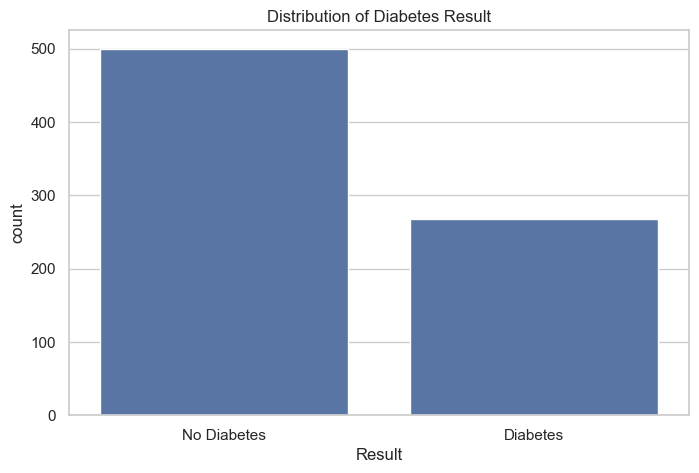

In [42]:
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.countplot(x='Result', data=df)
plt.title('Distribution of Diabetes Result')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show();

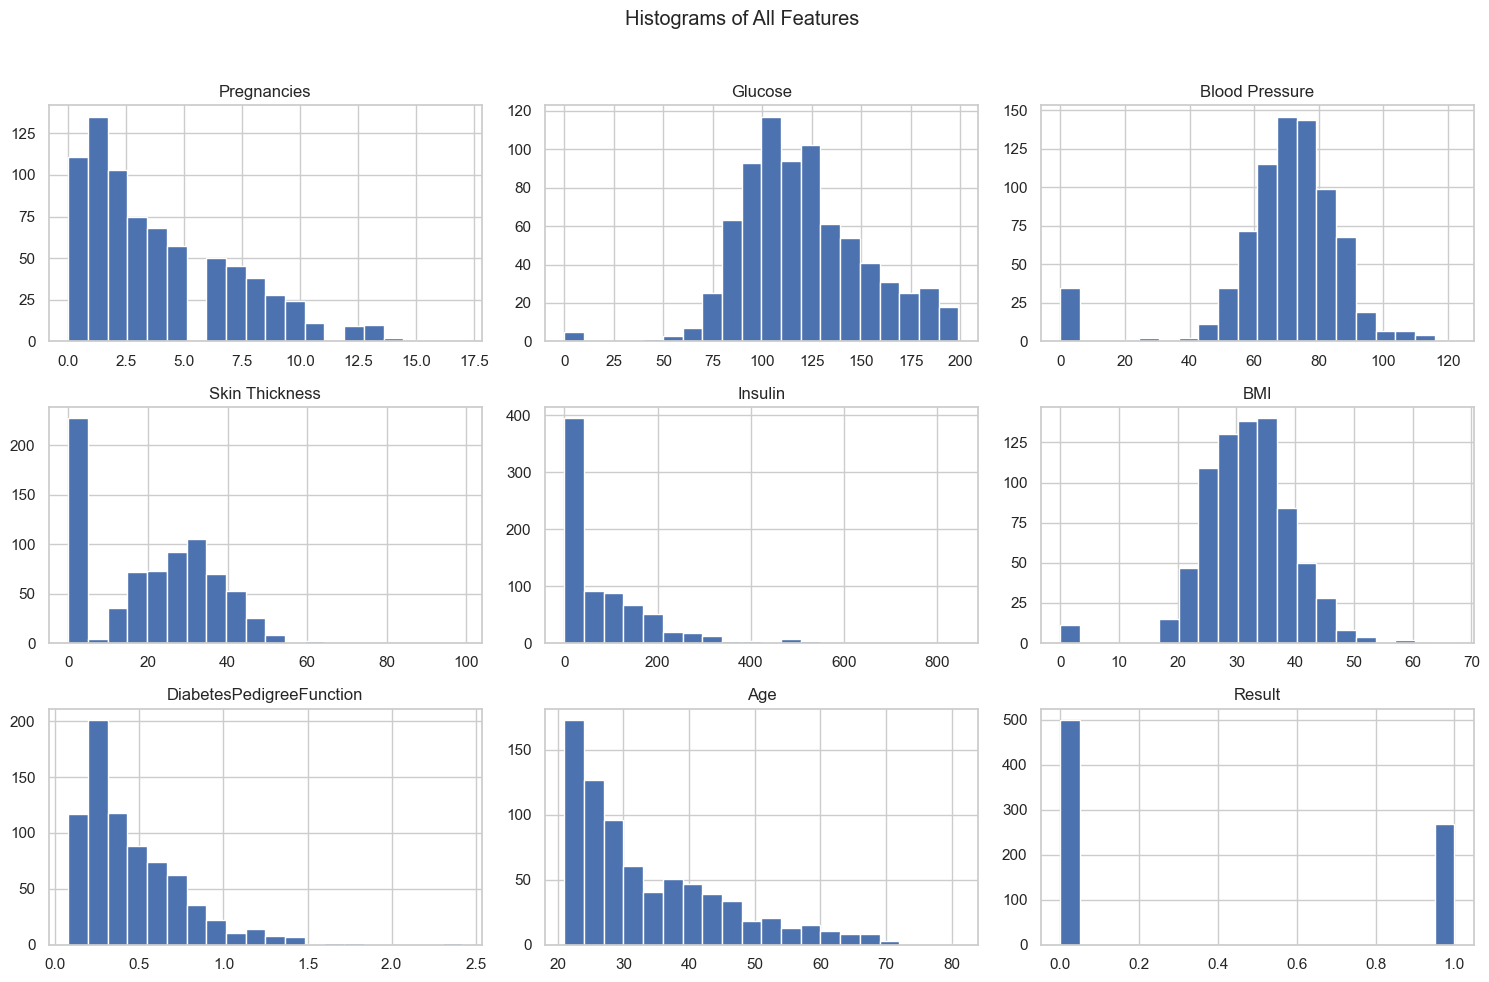

In [43]:
df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Histograms of All Features")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [44]:
#Data Cleaning

In [45]:
df

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Result
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [46]:
# Replace 0 values with NaN for specific columns
cols_to_clean = ['Glucose', 'Blood Pressure', 'Skin Thickness', 'Insulin', 'BMI']
for col in cols_to_clean:
    df[col] = df[col].replace(0, np.nan)

In [47]:
# Replace NaN values with the median of the column
for col in cols_to_clean:
    df[col].fillna(df[col].median(), inplace=True)

/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_20248/1173611747.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [48]:
df[cols_to_clean].describe()

,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.656250,72.386719,29.108073,140.671875,32.455208
std,30.438286,12.096642,8.791221,86.383060,6.875177
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,121.500000,27.500000
50%,117.000000,72.000000,29.000000,125.000000,32.300000
75%,140.250000,80.000000,32.000000,127.250000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


In [49]:
#3.2. Data Splitting and Scaling

In [50]:
X = df.drop('Result', axis=1)
y = df['Result']

In [53]:
X.shape

(768, 8)

In [54]:
y.shape

(768,)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=70, stratify=y)

In [76]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [77]:
X_train.shape

(614, 8)

In [78]:
X_test.shape

(154, 8)

In [79]:
#modeling and evaluation

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [81]:
models = {
    "Logistic Regression": LogisticRegression(random_state=70),
    "Random Forest": RandomForestClassifier(random_state=70),
    "Support Vector Machine": SVC(random_state=70)
}

In [82]:
results = {}

In [83]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {
        "Accuracy": accuracy,
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-Score": report['1']['f1-score']
    }

In [84]:
evaluation_df = pd.DataFrame(results)

In [85]:
evaluation_df

,Logistic Regression,Random Forest,Support Vector Machine
Accuracy,0.766234,0.759740,0.733766
Precision,0.736842,0.729730,0.724138
Recall,0.518519,0.500000,0.388889
F1-Score,0.608696,0.593407,0.506024


In [86]:
#testing

In [90]:
pregnancies = int(input("Enter number of pregnancies: "))
glucose = int(input("Enter Glucose level: "))
blood_pressure = int(input("Enter Blood Pressure: "))
skin_thickness = int(input("Enter Skin Thickness: "))
insulin = int(input("Enter Insulin level: "))
bmi = float(input("Enter BMI: "))
dpf = float(input("Enter Diabetes Pedigree Function value: "))
age = int(input("Enter age: "))

Enter number of pregnancies:  0
Enter Glucose level:  160
Enter Blood Pressure:  72
Enter Skin Thickness:  10
Enter Insulin level:  0
Enter BMI:  33.6
Enter Diabetes Pedigree Function value:  0.351
Enter age:  31


In [91]:
new_data = pd.DataFrame({
    'Pregnancies': [pregnancies],
    'Glucose': [glucose],
    'Blood Pressure': [blood_pressure],
    'Skin Thickness': [skin_thickness],
    'Insulin': [insulin],
    'BMI': [bmi],
    'DiabetesPedigreeFunction': [dpf],
    'Age': [age]
})

print("\n User Input DataFrame:")
print(new_data)


 User Input DataFrame:
   Pregnancies  Glucose  Blood Pressure  Skin Thickness  Insulin   BMI  \
0            0      160              72              10        0  33.6   

   DiabetesPedigreeFunction  Age  
0                     0.351   31  


In [92]:
new_data_scaled = scaler.transform(new_data)

In [94]:
prediction = model.predict(new_data_scaled)

In [95]:
if prediction[0] == 1:
    print("The model predicts that the person has Diabetes.")
else:
    print("The model predicts that the person does not have Diabetes.")

The model predicts that the person has Diabetes.


In [96]:
for model_name, model in models.items():
    prediction = model.predict(new_data_scaled)
    print(f"Prediction for {model_name}: {'Diabetes' if prediction[0] == 1 else 'Normal'}")

Prediction for Logistic Regression: Diabetes
Prediction for Random Forest: Diabetes
Prediction for Support Vector Machine: Diabetes
